# Email Spam Detector — Data Exploration

## Project Objective

The goal of this project is to build a machine learning system that classifies messages as either spam or legitimate (ham).

This notebook focuses on understanding and preparing the dataset before model development.

## Workflow

1. Load the dataset
2. Inspect the data
3. Understand the target labels
4. Check for missing values and duplicates
5. Explore the class distribution
6. Analyze message characteristics
7. Prepare the data for machine learning

In [1]:
import pandas as pd

In [2]:
file_path = "../data/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
label_counts = df["label"].value_counts()

label_percentages = df["label"].value_counts(normalize=True) * 100

label_percentages

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

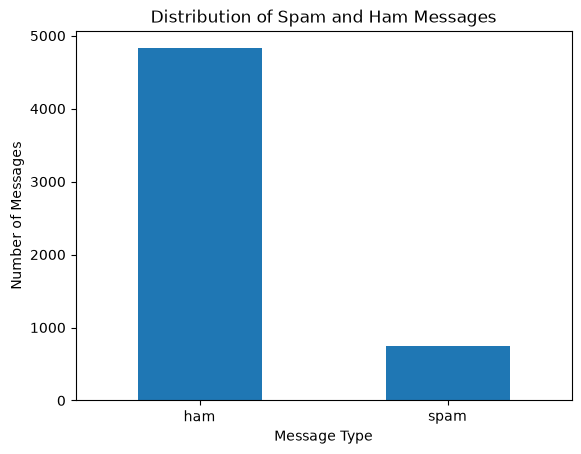

In [7]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

label_counts.plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()

In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
45,ham,No calls..messages..missed calls
62,ham,Its a part of checking IQ
65,spam,"As a valued customer, I am pleased to advise y..."
66,ham,"Today is ""song dedicated day.."" Which song wil..."


In [11]:
duplicate_label_counts = (
    duplicates.groupby("message")["label"]
    .nunique()
)

duplicate_label_counts.value_counts()

label
1    281
Name: count, dtype: int64

In [12]:
df_clean = df.drop_duplicates().copy()

In [13]:
df_clean.shape

(5169, 2)

In [14]:
df_clean.duplicated().sum()

np.int64(0)

In [15]:
df_clean["message_length"] = df_clean["message"].str.len()

In [16]:
df_clean[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
df_clean["message_length"].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64

In [18]:
df_clean.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


In [19]:
import matplotlib.pyplot as plt

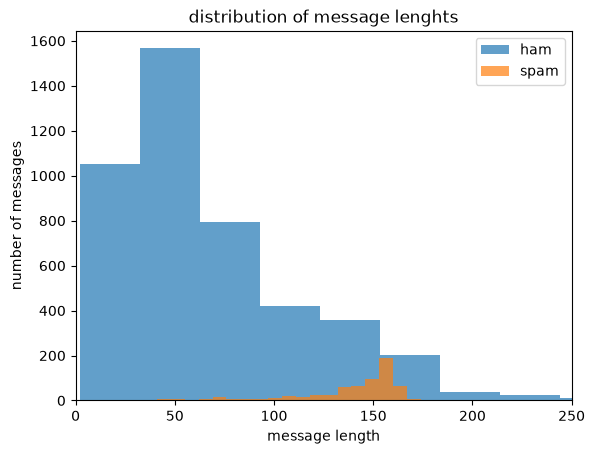

In [20]:
plt.hist(
    df_clean[df_clean["label"] == "ham"]["message_length"],
    bins=30,
    alpha=0.7,
    label="ham"
)
plt.hist(
    df_clean[df_clean["label"] == "spam"]["message_length"],
    bins=30,
    alpha=0.7,
    label="spam"
)

plt.xlim(0, 250)

plt.xlabel("message length")
plt.ylabel("number of messages")
plt.title("distribution of message lenghts")
plt.legend()
plt.show()

In [21]:
df_clean[df_clean["label"] == "spam"]["message"].head(10)

2     Free entry in 2 a wkly comp to win FA Cup fina...
5     FreeMsg Hey there darling it's been 3 week's n...
8     WINNER!! As a valued network customer you have...
9     Had your mobile 11 months or more? U R entitle...
11    SIX chances to win CASH! From 100 to 20,000 po...
12    URGENT! You have won a 1 week FREE membership ...
15    XXXMobileMovieClub: To use your credit, click ...
19    England v Macedonia - dont miss the goals/team...
34    Thanks for your subscription to Ringtone UK yo...
42    07732584351 - Rodger Burns - MSG = We tried to...
Name: message, dtype: str

In [22]:
from collections import Counter

spam_messages = df_clean[df_clean["label"] == "spam"]["message"]

spam_words = " ".join(spam_messages).lower().split()

spam_word_counts = Counter(spam_words)

spam_word_counts.most_common(20)

[('to', 594),
 ('a', 330),
 ('call', 298),
 ('your', 241),
 ('you', 226),
 ('for', 183),
 ('the', 181),
 ('free', 157),
 ('or', 157),
 ('2', 151),
 ('is', 138),
 ('on', 119),
 ('ur', 119),
 ('from', 118),
 ('have', 115),
 ('txt', 114),
 ('and', 104),
 ('text', 96),
 ('u', 96),
 ('mobile', 95)]

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spam_words_no_stopwords = [
    word for word in spam_words
    if word not in ENGLISH_STOP_WORDS
]

spam_word_counts_no_stopwords = Counter(spam_words_no_stopwords)

spam_word_counts_no_stopwords.most_common(20)

[('free', 157),
 ('2', 151),
 ('ur', 119),
 ('txt', 114),
 ('text', 96),
 ('u', 96),
 ('mobile', 95),
 ('reply', 93),
 ('claim', 89),
 ('&', 89),
 ('stop', 84),
 ('4', 75),
 ('just', 67),
 ('new', 64),
 ('send', 56),
 ('now!', 54),
 ('prize', 53),
 ('won', 53),
 ('nokia', 53),
 ('contact', 51)]

In [24]:
ham_messages = df_clean[df_clean["label"] == "ham"]["message"]

ham_words = " ".join(ham_messages).lower().split()

ham_words_no_stopwords = [
    word for word in ham_words
    if word not in ENGLISH_STOP_WORDS
]

ham_word_counts = Counter(ham_words_no_stopwords)

ham_word_counts.most_common(20)

[('u', 801),
 ("i'm", 358),
 ('2', 276),
 ('just', 274),
 ('&lt;#&gt;', 254),
 ('got', 222),
 ('like', 214),
 ('come', 202),
 ('ur', 200),
 ('know', 197),
 ('?', 178),
 ('good', 173),
 ('.', 160),
 ('...', 159),
 ('ü', 157),
 ('4', 157),
 ('going', 152),
 ('want', 150),
 ('ok', 146),
 ('time', 145)]

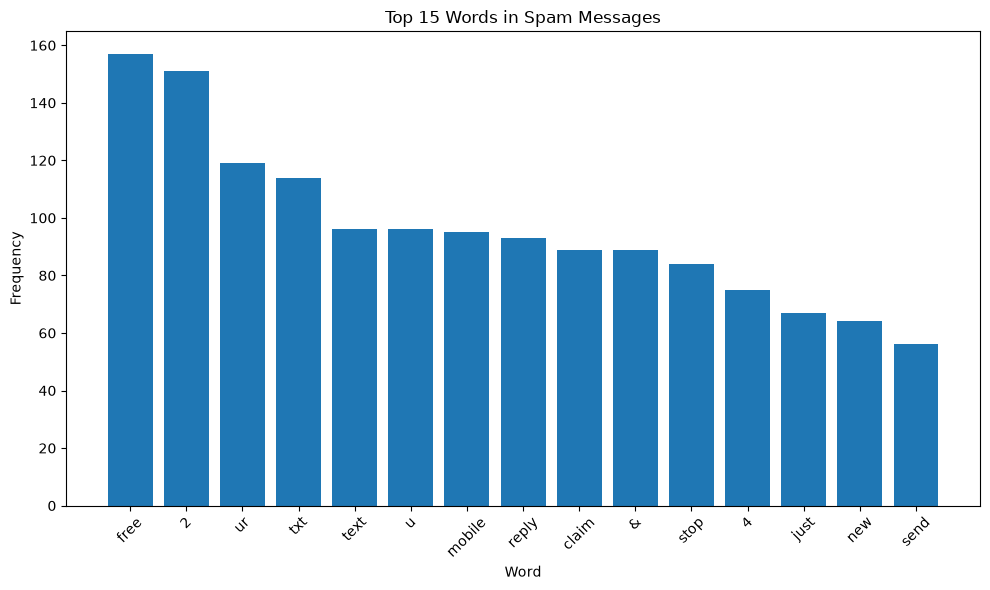

In [25]:
top_spam_words = spam_word_counts_no_stopwords.most_common(15)

words = [word for word, count in top_spam_words]
counts = [count for word, count in top_spam_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 15 Words in Spam Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
X = df_clean["message"]
y = df_clean["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", X_train.shape)
print("Testing messages:", X_test.shape)

Training messages: (4135,)
Testing messages: (1034,)


In [28]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
label
ham     87.376058
spam    12.623942
Name: proportion, dtype: float64

Testing set:
label
ham     87.330754
spam    12.669246
Name: proportion, dtype: float64


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [30]:
X_train_tfidf = tfidf.fit_transform(X_train)

print(X_train_tfidf.shape)

(4135, 7680)


In [31]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 7680


In [32]:
print(type(X_train_tfidf))

<class 'scipy.sparse._csr.csr_matrix'>


In [33]:
print(X_train_tfidf.nnz)

54735


In [34]:
total_values = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]

non_zero_percentage = (X_train_tfidf.nnz / total_values) * 100

print("Total possible values:", total_values)
print("Non-zero values:", X_train_tfidf.nnz)
print("Non-zero percentage:", non_zero_percentage)

Total possible values: 31756800
Non-zero values: 54735
Non-zero percentage: 0.17235678657799275


In [35]:
print(X_train.iloc[0])

Ta-Daaaaa! I am home babe, are you still up ?


In [36]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (1, 7680)>
  Coords	Values
  (0, 6620)	0.46972053147573545
  (0, 2121)	0.5494390936793128
  (0, 926)	0.27302453527471554
  (0, 3431)	0.28681222213960167
  (0, 1175)	0.32889978169730083
  (0, 1034)	0.22262669782699995
  (0, 7644)	0.14137598054893938
  (0, 6426)	0.2883706884664802
  (0, 7123)	0.24452632207532418


In [37]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[6620])

ta


In [38]:
feature_names = tfidf.get_feature_names_out()

row = X_train_tfidf[0]

for index, value in zip(row.indices, row.data):
    print(f"{feature_names[index]} → {value:.4f}")

ta → 0.4697
daaaaa → 0.5494
am → 0.2730
home → 0.2868
babe → 0.3289
are → 0.2226
you → 0.1414
still → 0.2884
up → 0.2445


In [39]:
X_test_tfidf = tfidf.transform(X_test)

In [40]:
print(X_test_tfidf.shape)

(1034, 7680)


In [41]:
print(y_train.head())

336     ham
390     ham
582     ham
1387    ham
1095    ham
Name: label, dtype: str


In [42]:
print(y_train.unique())

<StringArray>
['ham', 'spam']
Length: 2, dtype: str


In [43]:
y_train_encoded = y_train.map({"ham": 0, "spam": 1})
y_test_encoded = y_test.map({"ham": 0, "spam": 1})

In [44]:
print(y_train_encoded.head())
print(y_train_encoded.unique())

336     0
390     0
582     0
1387    0
1095    0
Name: label, dtype: int64
[0 1]


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

In [46]:
model.fit(X_train_tfidf, y_train_encoded)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [47]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [48]:
print("Predicted:", y_pred[:20])
print("Actual:   ", y_test_encoded.iloc[:20].to_numpy()) 

Predicted: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[899   4]
 [ 33  98]]


In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100) #percentage

Accuracy: 0.9642166344294004
Accuracy (%): 96.42166344294004


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_encoded, y_pred)

recall = recall_score(y_test_encoded, y_pred)

f1 = f1_score(y_test_encoded, y_pred)

print("Precision:", precision * 100)
print("Recall:", recall * 100)
print("f1:", f1 * 100)

Precision: 96.07843137254902
Recall: 74.80916030534351
f1: 84.12017167381974


In [52]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

print("Feature names:", feature_names.shape)
print("Coefficients:", coefficients.shape)

Feature names: (7680,)
Coefficients: (7680,)


In [53]:
top_spam_indices = coefficients.argsort()[-20:][::-1]

print(top_spam_indices)

[1601 7030 6728 2936 5666 6436 4498 7578 7058 1814 6871 7649  291 5373
 1891  524 2975 4927 1740 5973]


In [54]:
for index in top_spam_indices:
    print(f"{feature_names[index]} → {coefficients[index]:.4f}")

call → 4.2834
txt → 3.9820
text → 3.2730
free → 3.2586
reply → 3.0706
stop → 3.0157
mobile → 2.9673
www → 2.9340
uk → 2.7448
claim → 2.7250
to → 2.6514
your → 2.4200
150p → 2.3700
prize → 2.3268
com → 2.2757
50 → 2.2121
from → 2.1713
or → 2.0907
chat → 2.0901
service → 2.0623


In [55]:
top_ham_indices = coefficients.argsort()[:20]

for index in top_ham_indices:
    print(f"{feature_names[index]} → {coefficients[index]:.4f}")

me → -2.3738
my → -2.2489
that → -1.6756
it → -1.4799
ok → -1.4672
gt → -1.4652
lt → -1.4626
but → -1.4519
how → -1.3215
can → -1.2911
da → -1.2750
so → -1.2419
in → -1.2317
at → -1.2300
am → -1.2070
going → -1.1874
ll → -1.1621
come → -1.1542
he → -1.1541
its → -1.0998


In [56]:
message = X_test.iloc[0]

print("Message:", message)

Message: Good morning, my Love ... I go to sleep now and wish you a great day full of feeling better and opportunity ... You are my last thought babe, I LOVE YOU *kiss*


In [57]:
message_tfidf = tfidf.transform([message])

print("TF-IDF shape:", message_tfidf.shape)

TF-IDF shape: (1, 7680)


In [58]:
feature_names = tfidf.get_feature_names_out()

for index, value in zip(message_tfidf.indices, message_tfidf.data):
    print(f"{feature_names[index]} → {value:.4f}")

and → 0.2157
are → 0.1304
babe → 0.1927
better → 0.2197
day → 0.1612
feeling → 0.2521
full → 0.2399
go → 0.1506
good → 0.1552
great → 0.1843
kiss → 0.2325
last → 0.1951
love → 0.3313
morning → 0.2011
my → 0.2380
now → 0.1293
of → 0.1232
opportunity → 0.2960
sleep → 0.2111
thought → 0.2111
to → 0.0819
wish → 0.2173
you → 0.2484


In [59]:
for index, value in zip(message_tfidf.indices, message_tfidf.data):
    contribution = value * coefficients[index]
    print(
        f"{feature_names[index]} → "
        f"TF-IDF: {value:.4f}, "
        f"Coefficient: {coefficients[index]:.4f}, "
        f"Contribution: {contribution:.4f}"
    )

and → TF-IDF: 0.2157, Coefficient: -0.3051, Contribution: -0.0658
are → TF-IDF: 0.1304, Coefficient: -0.1405, Contribution: -0.0183
babe → TF-IDF: 0.1927, Coefficient: -0.1821, Contribution: -0.0351
better → TF-IDF: 0.2197, Coefficient: -0.1959, Contribution: -0.0430
day → TF-IDF: 0.1612, Coefficient: -0.6076, Contribution: -0.0979
feeling → TF-IDF: 0.2521, Coefficient: 0.0967, Contribution: 0.0244
full → TF-IDF: 0.2399, Coefficient: -0.2384, Contribution: -0.0572
go → TF-IDF: 0.1506, Coefficient: -0.5948, Contribution: -0.0896
good → TF-IDF: 0.1552, Coefficient: -0.8291, Contribution: -0.1286
great → TF-IDF: 0.1843, Coefficient: -0.3191, Contribution: -0.0588
kiss → TF-IDF: 0.2325, Coefficient: -0.1745, Contribution: -0.0406
last → TF-IDF: 0.1951, Coefficient: -0.0386, Contribution: -0.0075
love → TF-IDF: 0.3313, Coefficient: -0.5542, Contribution: -0.1836
morning → TF-IDF: 0.2011, Coefficient: -0.4799, Contribution: -0.0965
my → TF-IDF: 0.2380, Coefficient: -2.2489, Contribution: -0.

In [60]:
decision_score = model.decision_function(message_tfidf)

print("Decision score:", decision_score[0])

Decision score: -3.9327199503135093


In [61]:
probabilities = model.predict_proba(message_tfidf)

print("Ham probability:", probabilities[0][0])
print("Spam probability:", probabilities[0][1])

Ham probability: 0.9807860911952151
Spam probability: 0.019213908804784928


In [62]:
prediction = model.predict(message_tfidf)

print("Prediction:", prediction[0])

Prediction: 0


## Error Analysis

In [97]:
results = X_test.to_frame(name="message") #creating a new data frame and culmns 

results["actual"] = y_test_encoded
results["predicted"] = y_pred

In [64]:
false_negatives = results[
    (results["actual"] == 1) & (results["predicted"] == 0)
]

print("Number of false negatives:", len(false_negatives)) #sanity check

Number of false negatives: 33


In [98]:
false_negatives[["message"]].head(10) #spam message classified as ham(FP)

,message
5537,Want explicit SEX in 30 secs? Ring 02073162414...
529,You will recieve your tone within the next 24h...
2830,Send a logo 2 ur lover - 2 names joined by a h...
492,Congrats! 1 year special cinema pass for 2 is ...
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...
5098,TheMob>Hit the link to get a premium Pink Pant...
1449,As a registered optin subscriber ur draw 4 £10...
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
4673,Customer service announcement. We recently tri...
1699,"Free msg. Sorry, a service you ordered from 81..."


In [66]:
missed_message = false_negatives.iloc[0]["message"]

print(missed_message)

Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX


In [67]:
missed_tfidf = tfidf.transform([missed_message])

print("Shape:", missed_tfidf.shape)
print("Non-zero features:", missed_tfidf.nnz)

Shape: (1, 7680)
Non-zero features: 10


In [70]:
decision_score = model.decision_function(missed_tfidf)[0]
probabilities = model.predict_proba(missed_tfidf)[0]
prediction = model.predict(missed_tfidf)[0]

print("Decision score:", decision_score)
print("Ham probability:", probabilities[0] * 100)
print("Spam probability:", probabilities[1] * 100)
print("Prediction:", prediction)

Decision score: -1.8219167210186809
Ham probability: 86.07959594486063
Spam probability: 13.920404055139368
Prediction: 0


In [71]:
for index, tfidf_value in zip(missed_tfidf.indices, missed_tfidf.data):
    word = feature_names[index]
    coefficient = coefficients[index]
    contribution = tfidf_value * coefficient

    print(
        f"{word} → "
        f"TF-IDF: {tfidf_value:.4f}, "
        f"Coefficient: {coefficient:.4f}, "
        f"Contribution: {contribution:.4f}"
    )

20p → TF-IDF: 0.4024, Coefficient: 0.2533, Contribution: 0.1019
30 → TF-IDF: 0.3512, Coefficient: -0.1761, Contribution: -0.0618
costs → TF-IDF: 0.4170, Coefficient: 0.0819, Contribution: 0.0341
in → TF-IDF: 0.1484, Coefficient: -1.2317, Contribution: -0.1828
min → TF-IDF: 0.2776, Coefficient: 1.1175, Contribution: 0.3102
now → TF-IDF: 0.1758, Coefficient: 1.6196, Contribution: 0.2848
pobox → TF-IDF: 0.3512, Coefficient: 0.6681, Contribution: 0.2346
ring → TF-IDF: 0.3354, Coefficient: -0.0617, Contribution: -0.0207
sex → TF-IDF: 0.3560, Coefficient: 0.4240, Contribution: 0.1509
want → TF-IDF: 0.2198, Coefficient: -0.6509, Contribution: -0.1431


In [73]:
contribution_sum = 0

for index, tfidf_value in zip(missed_tfidf.indices, missed_tfidf.data):
    coefficient = coefficients[index]
    contribution = tfidf_value * coefficient
    contribution_sum += contribution

intercept = model.intercept_[0]
reconstructed_score = intercept + contribution_sum

print("Sum of feature contributions:", contribution_sum)
print("Intercept:", intercept)
print("Reconstructed decision score:", reconstructed_score)
print("Model decision score:", model.decision_function(missed_tfidf)[0])

Sum of feature contributions: 0.7081334569790123
Intercept: -2.530050177997693
Reconstructed decision score: -1.8219167210186809
Model decision score: -1.8219167210186809


In [74]:
analyzer = tfidf.build_analyzer() #investigate the missing words

tokens = analyzer(missed_message)

print(tokens)

['want', 'explicit', 'sex', 'in', '30', 'secs', 'ring', '02073162414', 'now', 'costs', '20p', 'min', 'gsex', 'pobox', '2667', 'wc1n', '3xx']


In [80]:
known_tokens = [] # empty lists
oov_tokens = []  # empty lists + OOV — Out Of Vocabulary

for token in tokens:
    if token in tfidf.vocabulary_:
        known_tokens.append(token)
    else:                                  # add one item to the end of a list
        oov_tokens.append(token)
        
print("Known tokens:", known_tokens)
print("Oov token:", oov_tokens)
print("Numbers of known tokens:", len(known_tokens))
print("Numbers of oove tokens:", len(oov_tokens))

Known tokens: ['want', 'sex', 'in', '30', 'ring', 'now', 'costs', '20p', 'min', 'pobox']
Oov token: ['explicit', 'secs', '02073162414', 'gsex', '2667', 'wc1n', '3xx']
Numbers of known tokens: 10
Numbers of oove tokens: 7


In [81]:
def count_oov_tokens(message): #create a function to check missing vocabularies
    tokens = analyzer(message)

    oov_tokens = [
        token
        for token in tokens
        if token not in tfidf.vocabulary_
    ]

    return len(tokens), len(oov_tokens) #returning two values 

In [82]:
count_oov_tokens(missed_message)

(17, 7)

In [88]:
oov_analysis = false_negatives["message"].apply(count_oov_tokens) #apply function to all 33 False nagative

oov_analysis.head(33)

5537    (17, 7)
529     (19, 2)
2830    (26, 7)
492     (24, 0)
1663    (24, 4)
5098    (24, 6)
1449    (25, 3)
5540    (28, 7)
4673    (25, 2)
1699    (26, 0)
1469    (24, 5)
4213    (11, 1)
672     (18, 1)
1718    (25, 3)
878     (24, 0)
1460    (13, 1)
1895    (30, 3)
2402    (27, 4)
4821    (11, 5)
2269     (6, 1)
4144    (27, 3)
788     (22, 1)
4394    (10, 1)
3530    (31, 0)
5449    (12, 3)
3290    (15, 0)
4475    (12, 3)
1875    (19, 1)
415      (6, 2)
3981     (2, 1)
3750    (22, 3)
420     (26, 7)
2770    (26, 5)
Name: message, dtype: object

In [89]:
false_negatives = false_negatives.copy() #I want to modify this new DataFrame independently 

false_negatives[["total_tokens", "oov_tokens"]] = oov_analysis.apply(
    lambda x: pd.Series(x) # anonymous function
)

In [90]:
false_negatives["oov_rate"] = (
    false_negatives["oov_tokens"]
    / false_negatives["total_tokens"]
) * 100

In [92]:
false_negatives[
    ["message", "total_tokens", "oov_tokens", "oov_rate"]
].head(10)

,message,total_tokens,oov_tokens,oov_rate
5537,Want explicit SEX in 30 secs? Ring 02073162414...,17,7,41.176471
529,You will recieve your tone within the next 24h...,19,2,10.526316
2830,Send a logo 2 ur lover - 2 names joined by a h...,26,7,26.923077
492,Congrats! 1 year special cinema pass for 2 is ...,24,0,0.000000
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...,24,4,16.666667
5098,TheMob>Hit the link to get a premium Pink Pant...,24,6,25.000000
1449,As a registered optin subscriber ur draw 4 £10...,25,3,12.000000
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,28,7,25.000000
4673,Customer service announcement. We recently tri...,25,2,8.000000
1699,"Free msg. Sorry, a service you ordered from 81...",26,0,0.000000


In [96]:
false_negatives["oov_rate"].describe()

count    33.000000
mean     16.104361
std      13.152952
min       0.000000
25%       7.692308
50%      12.000000
75%      25.000000
max      50.000000
Name: oov_rate, dtype: float64

In [100]:
true_positives = results[
    (results["actual"] == 1) & (results["predicted"] == 1)
].copy()

print("Number of true positives:", len(true_positives))

Number of true positives: 98


In [101]:
true_positive_oov = true_positives["message"].apply(count_oov_tokens)

true_positives[["total_tokens", "oov_tokens"]] = pd.DataFrame(
    true_positive_oov.tolist(),
    index=true_positives.index
)